## Text Extraction

In [1]:
!pip install -q pymupdf python-docx pandas

!pip install reportlab

!apt-get update -qq
!apt-get install -y -qq libreoffice

!soffice --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.0 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Preconfiguring packages ...
Selecting previously unselected package fonts-opensymbol.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../000-fonts-opensymbol_2%3a102.12+LibO7.3.7-0ubuntu0.22.04.10_all.deb ...
Unpacking fonts-opensymbol (2:102.12+LibO7.3.7-0ubuntu0.22.04.10) ...
Selecting previously unselected package libreoffice-style-colibre.
Preparing to unpack .../001-libreoffice-style-colibre_1%3a7.3.7-0ubuntu0.22.04.10_all.deb ...
Unpacking libreoffice-style-colibre (1:7.3.7-0ubuntu0.22.04.10) ...
Selecting previously unselected package libuno-sal3.
Prep

In [2]:
import pandas as pd
import numpy as np
import fitz ## PyMuPDF
import re
import hashlib
import json
import time
import subprocess
import matplotlib.pyplot as plt
import zipfile

from pathlib import Path
from docx import Document
from google.colab import drive
from IPython.display import display, HTML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

In [3]:
## find zip
zip_files = list(Path("/content").glob("*.zip"))

if len(zip_files) == 0:
    raise ValueError("No ZIP file found. Please upload one.")

zip_path = zip_files[0]
print(f"Using: {zip_path.name}")

## extract
extract_path = Path("/content/input_data")
extract_path.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

DATA_PATH = extract_path

print("\n✅ Done!")
print("DATA_PATH =", DATA_PATH)

print("\nPreview:")
for f in DATA_PATH.rglob("*"):
    print("-", f)

Using: _final docs.zip

✅ Done!
DATA_PATH = /content/input_data

Preview:
- /content/input_data/_final docs
- /content/input_data/__MACOSX
- /content/input_data/_final docs/10. Grad Students 2025 final.docx
- /content/input_data/_final docs/archives
- /content/input_data/_final docs/.DS_Store
- /content/input_data/_final docs/9. Post Doc 2025 final.docx
- /content/input_data/_final docs/1. External Faculty 2025 final.pdf
- /content/input_data/_final docs/5. Faculty & Researcher Presentations & Meeting Participation 2025 final.docx
- /content/input_data/_final docs/8. Faculty & Researcher National & International Service 2025 final.pdf
- /content/input_data/_final docs/6. Faculty and Researcher Awards & Recognition 2025 final.docx
- /content/input_data/_final docs/8. Faculty & Researcher National & International Service 2025 final.docx
- /content/input_data/_final docs/7. Faculty & Researcher Local & State Service 2025 final.docx
- /content/input_data/_final docs/10. Grad Students 2025 

In [4]:
BASE = DATA_PATH

In [5]:
## non-nested target file aggregation
rows = []

## constants
TARGET_KEYWORDS = ["final", "lb"]
TARGET_EXTENSIONS = [".pdf", ".docx"]

## input folder
input_folder = BASE  ## or whatever your uploaded folder path is

## missing input folder check
if not input_folder.exists():
    raise ValueError(f"Input folder does not exist: {input_folder}")

## find target files directly inside input folder only
all_files = [
    f for f in input_folder.rglob("*")
    if f.is_file()
    and "__MACOSX" not in f.parts
    and not f.name.startswith("._")
    and f.name != ".DS_Store"
]

## find target files
target_files = []

for f in all_files:
    name_lower = f.name.lower()
    ext = f.suffix.lower()

    if ext in TARGET_EXTENSIONS and any(keyword in name_lower for keyword in TARGET_KEYWORDS):
        target_files.append(f)

## record results
if not target_files:
    rows.append({
        "status": "no_target_files_found",
        "file_path": None,
        "ext": None
    })
else:
    for f in target_files:
        rows.append({
            "status": "target_file_found",
            "file_path": str(f),
            "file_name": f.name,
            "ext": f.suffix.lower()
        })

df_target_files = pd.DataFrame(rows)

print("input folder:", input_folder)
print("target files found:", len(target_files))

input folder: /content/input_data
target files found: 18


In [6]:
## clean filename down to a shared core title
def make_core_title(name: str) -> str:
    if not isinstance(name, str):
        return ""

    s = Path(name).stem.lower().strip()

    ## remove leading punctuation (., -, _) before anything
    s = re.sub(r"^[\s\.\-_]+", "", s)

    ## remove leading numbering like "1. ", "10. ", "1 - ", "1 "
    s = re.sub(r"^\d+\.\s*", "", s)
    s = re.sub(r"^\d+\s*-\s*", "", s)
    s = re.sub(r"^\d+\s+", "", s)

    ## normalize symbols
    s = s.replace("&", "and")

    ## remove common tags
    s = re.sub(r"\bfinal\b", "", s)
    s = re.sub(r"\blb\b", "", s)

    ## remove dates like 5-30-25, 05-30-2025, etc.
    s = re.sub(r"\b\d{1,2}-\d{1,2}-\d{2,4}\b", "", s)

    ## normalize separators
    s = re.sub(r"[_\-]+", " ", s)

    ## collapse whitespace
    s = re.sub(r"\s+", " ", s).strip()

    return s


## build dataframe
df_target_files = pd.DataFrame(rows)

## keep only valid target files
df_target_files = df_target_files[
    df_target_files["status"] == "target_file_found"
].copy()

## extract filename
df_target_files["file_name"] = df_target_files["file_path"].apply(
    lambda x: Path(x).name if pd.notna(x) else None
)

## create normalized core title
df_target_files["core_title"] = df_target_files["file_name"].apply(make_core_title)

## extension preference (lower is better)
ext_priority = {
    ".pdf": 1,
    ".docx": 2,
    ".doc": 3
}

df_target_files["ext_rank"] = df_target_files["ext"].map(ext_priority).fillna(99)

## sort so best file (pdf) comes first within each group
df_target_files = df_target_files.sort_values(
    ["core_title", "ext_rank", "file_name"]
).copy()

## deduplicate based on normalized title
df_target_files_dedup = df_target_files.drop_duplicates(
    subset=["core_title"],
    keep="first"
).copy()

## summary stats
print("before dedup:", len(df_target_files))
print("after dedup:", len(df_target_files_dedup))
print("removed:", len(df_target_files) - len(df_target_files_dedup))

## optional: inspect duplicates that were removed
dupes = df_target_files[df_target_files.duplicated("core_title", keep=False)]
print("\nDuplicate groups preview:")
display(dupes[["file_name", "core_title", "ext"]].sort_values("core_title"))

## final output
df_target_files_dedup.head()

before dedup: 18
after dedup: 9
removed: 9

Duplicate groups preview:


,file_name,core_title,ext
2,1. External Faculty 2025 final.pdf,external faculty 2025,.pdf
12,1. External Faculty 2025 final.docx,external faculty 2025,.docx
9,6. Faculty and Researcher Awards & Recognition...,faculty and researcher awards and recognition ...,.pdf
5,6. Faculty and Researcher Awards & Recognition...,faculty and researcher awards and recognition ...,.docx
13,3. Faculty and Researcher Grant Funding 2025 f...,faculty and researcher grant funding 2025,.pdf
16,3. Faculty and Researcher Grant Funding 2025 f...,faculty and researcher grant funding 2025,.docx
17,7. Faculty & Researcher Local & State Service ...,faculty and researcher local and state service...,.pdf
7,7. Faculty & Researcher Local & State Service ...,faculty and researcher local and state service...,.docx
6,8. Faculty & Researcher National & Internation...,faculty and researcher national and internatio...,.docx
4,8. Faculty & Researcher National & Internation...,faculty and researcher national and internatio...,.pdf


,status,file_path,file_name,ext,core_title,ext_rank
2,target_file_found,/content/input_data/_final docs/1. External Fa...,1. External Faculty 2025 final.pdf,.pdf,external faculty 2025,1
9,target_file_found,/content/input_data/_final docs/6. Faculty and...,6. Faculty and Researcher Awards & Recognition...,.pdf,faculty and researcher awards and recognition ...,1
13,target_file_found,/content/input_data/_final docs/3. Faculty and...,3. Faculty and Researcher Grant Funding 2025 f...,.pdf,faculty and researcher grant funding 2025,1
17,target_file_found,/content/input_data/_final docs/7. Faculty & R...,7. Faculty & Researcher Local & State Service ...,.pdf,faculty and researcher local and state service...,1
4,target_file_found,/content/input_data/_final docs/8. Faculty & R...,8. Faculty & Researcher National & Internation...,.pdf,faculty and researcher national and internatio...,1


In [7]:
## table of leftover files with paths
leftover_table = (
    df_target_files_dedup[["file_name", "ext"]]
    .sort_values(["file_name"])
    .reset_index(drop=True)
)

leftover_table

,file_name,ext
0,1. External Faculty 2025 final.pdf,.pdf
1,10. Grad Students 2025 final.pdf,.pdf
2,3. Faculty and Researcher Grant Funding 2025 f...,.pdf
3,4. Faculty & Researcher Scholarly Work 2025 fi...,.pdf
4,5. Faculty & Researcher Presentations & Meetin...,.pdf
5,6. Faculty and Researcher Awards & Recognition...,.pdf
6,7. Faculty & Researcher Local & State Service ...,.pdf
7,8. Faculty & Researcher National & Internation...,.pdf
8,9. Post Doc 2025 final.pdf,.pdf


In [8]:
## folder to store converted .doc files
BASE_CONVERTED = Path("/content/converted_docx")
BASE_CONVERTED.mkdir(parents=True, exist_ok=True)


## conversion function
def convert_doc_to_docx(src_doc: Path, dst_docx: Path) -> tuple[bool, str]:
    try:
        dst_docx.parent.mkdir(parents=True, exist_ok=True)

        ## skip if converted file already exists and is current
        if dst_docx.exists() and dst_docx.stat().st_mtime >= src_doc.stat().st_mtime:
            return True, "skipped_up_to_date"

        cmd = [
            "soffice", "--headless", "--nologo", "--nofirststartwizard",
            "--convert-to", "docx",
            "--outdir", str(dst_docx.parent),
            str(src_doc),
        ]

        r = subprocess.run(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )

        expected = dst_docx.parent / (src_doc.stem + ".docx")

        if r.returncode != 0:
            return False, f"convert_error: {r.stderr.strip()[:300]}"

        if not expected.exists():
            return False, "convert_error: output_missing"

        if expected.resolve() != dst_docx.resolve():
            expected.replace(dst_docx)

        return True, "converted"

    except Exception as e:
        return False, f"convert_error: {str(e)}"


## isolate leftover .doc files from deduplicated target files
leftover_doc_df = df_target_files_dedup[
    df_target_files_dedup["ext"] == ".doc"
].copy()


## initialize counters
converted = 0
skipped = 0
failed = 0
fail_samples = []


## process only leftover .doc files
for _, row in leftover_doc_df.iterrows():

    src_doc = Path(row["file_path"])

    if not src_doc.exists():
        failed += 1
        if len(fail_samples) < 5:
            fail_samples.append((str(src_doc), "file_missing"))
        continue

    ## save converted file using same filename, but .docx extension
    dst_docx = BASE_CONVERTED / src_doc.with_suffix(".docx").name

    ok, msg = convert_doc_to_docx(src_doc, dst_docx)

    if ok and msg == "converted":
        converted += 1
    elif ok and msg == "skipped_up_to_date":
        skipped += 1
    else:
        failed += 1
        if len(fail_samples) < 5:
            fail_samples.append((str(src_doc), msg))


## print summary
print(f"DOC → DOCX conversion: converted={converted}, skipped_up_to_date={skipped}, failed={failed}")

if fail_samples:
    print("Sample failures:")
    for p, m in fail_samples:
        print(" ", p, "=>", m)

DOC → DOCX conversion: converted=0, skipped_up_to_date=0, failed=0


In [9]:
ALLOWED_EXTS = {".pdf", ".docx"}

## extract text from pdf using PyMuPDF
def extract_text_pdf(path: Path, block_gap_threshold=14):
    try:
        output_pages = []

        with fitz.open(path) as doc:
            for page in doc:
                text_dict = page.get_text("dict")
                extracted_lines = []

                ## collect text lines from text blocks only
                for block in text_dict["blocks"]:
                    if block["type"] != 0:
                        continue

                    for line in block["lines"]:
                        spans = line["spans"]
                        line_text = "".join(span["text"] for span in spans).strip()

                        if not line_text:
                            continue

                        x0 = min(span["bbox"][0] for span in spans)
                        y0 = min(span["bbox"][1] for span in spans)
                        x1 = max(span["bbox"][2] for span in spans)
                        y1 = max(span["bbox"][3] for span in spans)

                        extracted_lines.append({
                            "text": line_text,
                            "x0": x0,
                            "y0": y0,
                            "x1": x1,
                            "y1": y1,
                        })

                ## sort lines in reading order
                extracted_lines.sort(key=lambda ln: (round(ln["y0"], 1), ln["x0"]))

                if not extracted_lines:
                    output_pages.append("")
                    continue

                page_parts = [extracted_lines[0]["text"]]
                prev_line = extracted_lines[0]

                for line in extracted_lines[1:]:
                    vertical_gap = line["y0"] - prev_line["y1"]

                    if vertical_gap > block_gap_threshold:
                        page_parts.append("\n\n")
                    else:
                        page_parts.append("\n")

                    page_parts.append(line["text"])
                    prev_line = line

                output_pages.append("".join(page_parts).strip())

        return True, "\n\n".join(output_pages).strip(), None

    except Exception as e:
        return False, None, f"pdf_error: {str(e)}"


## extract text from docx using python-docx
def extract_text_docx(path: Path):
    try:
        doc = Document(path)
        text = "\n".join(p.text for p in doc.paragraphs)
        return True, text, None
    except Exception as e:
        return False, None, f"docx_error: {str(e)}"


## route file based on file extension
def extract_text_any(path: Path):
    ext = path.suffix.lower()

    if ext == ".pdf":
        return extract_text_pdf(path)

    if ext == ".docx":
        return extract_text_docx(path)

    return False, None, f"unsupported_ext: {ext}"


## preserve line breaks for downstream section/citation detection
def normalize_text_for_txt(text: str) -> str:
    if not text:
        return ""

    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


## if any .doc files were converted, point to converted .docx
def resolve_preferred_path(path_str: str) -> str:
    src = Path(path_str)

    if src.suffix.lower() == ".doc":
        converted = BASE_CONVERTED / src.with_suffix(".docx").name

        if converted.exists():
            return str(converted)

    return str(src)


## initialize extraction rows
corpus_rows = []
seen_doc_ids = set()


## extract from deduplicated target file table
def extract_from_target_table(df_files: pd.DataFrame):
    """
    df_files: deduplicated target file table
              should contain file_path, ext, file_name, and core_title
    """

    for _, row in df_files.iterrows():
        f = Path(row["file_path"])

        if not f.exists():
            corpus_rows.append({
                "doc_id": str(row["file_path"]),
                "core_title": row.get("core_title", None),
                "file_name": row.get("file_name", None),
                "path": str(row["file_path"]),
                "ext": row.get("ext", None),
                "ok": False,
                "fail_reason": "file_missing",
                "n_chars": 0,
                "n_words": 0,
                "text": None
            })
            continue

        ext = f.suffix.lower()

        if ext not in ALLOWED_EXTS:
            corpus_rows.append({
                "doc_id": str(f),
                "core_title": row.get("core_title", None),
                "file_name": f.name,
                "path": str(f),
                "ext": ext,
                "ok": False,
                "fail_reason": f"unsupported_ext: {ext}",
                "n_chars": 0,
                "n_words": 0,
                "text": None
            })
            continue

        ## use filename/core title as document identifier for this single-folder workflow
        doc_id = row.get("core_title", f.stem)

        if doc_id in seen_doc_ids:
            continue

        seen_doc_ids.add(doc_id)

        ok, text, reason = extract_text_any(f)

        if ok and text:
            text = normalize_text_for_txt(text)

        corpus_rows.append({
            "doc_id": doc_id,
            "core_title": row.get("core_title", None),
            "file_name": f.name,
            "path": str(f),
            "ext": ext,
            "ok": ok,
            "fail_reason": reason,
            "n_chars": len(text) if text else 0,
            "n_words": len(re.findall(r"\S+", text)) if text else 0,
            "text": text if ok else None
        })


## use deduplicated target files
extract_input_df = df_target_files_dedup.copy()

## resolve converted .doc files if applicable
extract_input_df["file_path"] = extract_input_df["file_path"].apply(resolve_preferred_path)
extract_input_df["ext"] = extract_input_df["file_path"].apply(lambda x: Path(x).suffix.lower())
extract_input_df["file_name"] = extract_input_df["file_path"].apply(lambda x: Path(x).name)

## extract text
extract_from_target_table(extract_input_df)

## final corpus table
df_target_corpus = pd.DataFrame(corpus_rows)

print("total documents:", len(df_target_corpus))
print("successful extractions:", df_target_corpus["ok"].sum())
print("failed extractions:", (~df_target_corpus["ok"]).sum())

df_target_corpus.head()

total documents: 9
successful extractions: 9
failed extractions: 0


,doc_id,core_title,file_name,path,ext,ok,fail_reason,n_chars,n_words,text
0,external faculty 2025,external faculty 2025,1. External Faculty 2025 final.pdf,/content/input_data/_final docs/1. External Fa...,.pdf,True,None,24702,3382,Johari Harris\n\nHONORS & AWARDS\n2025 Outstan...
1,faculty and researcher awards and recognition ...,faculty and researcher awards and recognition ...,6. Faculty and Researcher Awards & Recognition...,/content/input_data/_final docs/6. Faculty and...,.pdf,True,None,5821,796,Nancy Deutsch\n\nHONORS\n• Organizational Awar...
2,faculty and researcher grant funding 2025,faculty and researcher grant funding 2025,3. Faculty and Researcher Grant Funding 2025 f...,/content/input_data/_final docs/3. Faculty and...,.pdf,True,None,35485,4954,Nancy Deutsch\n\nGRANTS AND SPONSORED PROJECTS...
3,faculty and researcher local and state service...,faculty and researcher local and state service...,7. Faculty & Researcher Local & State Service ...,/content/input_data/_final docs/7. Faculty & R...,.pdf,True,None,13398,1857,Nancy Deutsch\n\nUNIVERSITY SERVICE\n• ITHRIVE...
4,faculty and researcher national and internatio...,faculty and researcher national and internatio...,8. Faculty & Researcher National & Internation...,/content/input_data/_final docs/8. Faculty & R...,.pdf,True,None,18414,2524,Nancy Deutsch\n\nNATIONAL ADVISORY BOARDS AND ...


In [10]:
## filter successful extractions
df_ok = df_target_corpus[df_target_corpus["ok"] == True].copy()

## define txt output folder (local Colab)
TXT_ROOT = Path("/content/youthnex_txt_spaces")
TXT_ROOT.mkdir(parents=True, exist_ok=True)


## safe filename function (prevents weird characters breaking files)
def safe_filename(name: str) -> str:
    name = str(name).lower().strip()
    name = re.sub(r"[^\w\s-]", "", name)   ## remove special chars
    name = re.sub(r"\s+", "_", name)       ## spaces → underscores
    return name[:120]                     ## avoid super long names


## write one .txt per document
saved = 0

for _, row in df_ok.iterrows():
    text = row["text"]
    if not text:
        continue

    ## choose best name (core_title preferred)
    base_name = row.get("core_title") or row.get("doc_id") or row.get("file_name")

    fname = safe_filename(base_name)
    txt_path = TXT_ROOT / f"{fname}.txt"

    txt_path.write_text(text, encoding="utf-8")
    saved += 1


## summary
print("txt files saved:", saved)
print("saved to:", TXT_ROOT)

txt files saved: 9
saved to: /content/youthnex_txt_spaces


## Bibliographic Extraction

In [11]:
## local Colab folder containing extracted .txt files
TXT_ROOT = Path("/content/youthnex_txt_spaces")
EXPORT_PREFIX = "biblio_stabilized"


def load_txt_corpus(txt_root: Path) -> pd.DataFrame:
    txt_root = Path(txt_root)

    if not txt_root.exists():
        raise FileNotFoundError(
            f"TXT_ROOT does not exist: {txt_root.resolve()}\n"
            "Point TXT_ROOT to the folder containing the preprocessed .txt files."
        )

    rows = []

    for txt_file in sorted(txt_root.rglob("*.txt")):
        rel = txt_file.relative_to(txt_root)
        text = txt_file.read_text(encoding="utf-8", errors="ignore")

        rows.append({
            "doc_id": txt_file.stem,
            "doc_uid": str(rel.with_suffix("")),
            "path": str(txt_file),
            "text": text,
        })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(f"No .txt files found under: {txt_root.resolve()}")

    return df


df_corpus = load_txt_corpus(TXT_ROOT)

print("Rows loaded:", len(df_corpus))
print("Unique doc_uid:", df_corpus["doc_uid"].nunique())
print("Unique doc_id:", df_corpus["doc_id"].nunique())

df_corpus.head()

Rows loaded: 9
Unique doc_uid: 9
Unique doc_id: 9


,doc_id,doc_uid,path,text
0,external_faculty_2025,external_faculty_2025,/content/youthnex_txt_spaces/external_faculty_...,Johari Harris\n\nHONORS & AWARDS\n2025 Outstan...
1,faculty_and_researcher_awards_and_recognition_...,faculty_and_researcher_awards_and_recognition_...,/content/youthnex_txt_spaces/faculty_and_resea...,Nancy Deutsch\n\nHONORS\n• Organizational Awar...
2,faculty_and_researcher_grant_funding_2025,faculty_and_researcher_grant_funding_2025,/content/youthnex_txt_spaces/faculty_and_resea...,Nancy Deutsch\n\nGRANTS AND SPONSORED PROJECTS...
3,faculty_and_researcher_local_and_state_service...,faculty_and_researcher_local_and_state_service...,/content/youthnex_txt_spaces/faculty_and_resea...,Nancy Deutsch\n\nUNIVERSITY SERVICE\n• ITHRIVE...
4,faculty_and_researcher_national_and_internatio...,faculty_and_researcher_national_and_internatio...,/content/youthnex_txt_spaces/faculty_and_resea...,Nancy Deutsch\n\nNATIONAL ADVISORY BOARDS AND ...


In [12]:
def normalize_text_multiline(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""

    text = text.replace("\r\n", "\n").replace("\r", "\n")
    lines = [ln.rstrip() for ln in text.split("\n")]

    cleaned = []
    blank_count = 0

    for ln in lines:
        if ln.strip() == "":
            blank_count += 1
            if blank_count <= 2:
                cleaned.append("")
        else:
            blank_count = 0
            cleaned.append(ln)

    return "\n".join(cleaned).strip()


def normalize_text_flat(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""

    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("\n", " ").replace("\t", " ")

    return re.sub(r"\s+", " ", text).strip()


## apply normalization
df_corpus["text_multiline"] = df_corpus["text"].fillna("").apply(normalize_text_multiline)
df_corpus["text_flat"] = df_corpus["text"].fillna("").apply(normalize_text_flat)

## quick check
print("documents normalized:", len(df_corpus))
print("empty multiline texts:", (df_corpus["text_multiline"] == "").sum())
print("empty flat texts:", (df_corpus["text_flat"] == "").sum())

df_corpus[["doc_uid", "path", "text_multiline", "text_flat"]].head()

documents normalized: 9
empty multiline texts: 0
empty flat texts: 0


,doc_uid,path,text_multiline,text_flat
0,external_faculty_2025,/content/youthnex_txt_spaces/external_faculty_...,Johari Harris\n\nHONORS & AWARDS\n2025 Outstan...,Johari Harris HONORS & AWARDS 2025 Outstanding...
1,faculty_and_researcher_awards_and_recognition_...,/content/youthnex_txt_spaces/faculty_and_resea...,Nancy Deutsch\n\nHONORS\n• Organizational Awar...,Nancy Deutsch HONORS • Organizational Award fo...
2,faculty_and_researcher_grant_funding_2025,/content/youthnex_txt_spaces/faculty_and_resea...,Nancy Deutsch\n\nGRANTS AND SPONSORED PROJECTS...,Nancy Deutsch GRANTS AND SPONSORED PROJECTS - ...
3,faculty_and_researcher_local_and_state_service...,/content/youthnex_txt_spaces/faculty_and_resea...,Nancy Deutsch\n\nUNIVERSITY SERVICE\n• ITHRIVE...,Nancy Deutsch UNIVERSITY SERVICE • ITHRIVE Men...
4,faculty_and_researcher_national_and_internatio...,/content/youthnex_txt_spaces/faculty_and_resea...,Nancy Deutsch\n\nNATIONAL ADVISORY BOARDS AND ...,Nancy Deutsch NATIONAL ADVISORY BOARDS AND WOR...


In [13]:
## expanded publication keyword detection
PUB_ANYWHERE_RE = re.compile(
    r"publicat|bibliograph|journal|article|peer[- ]reviewed|refereed|book chapter|scholarly work|papers?",
    flags=re.IGNORECASE
)

diag_rows = []

for _, row in df_corpus.iterrows():
    text = row["text_multiline"]

    m = PUB_ANYWHERE_RE.search(text)

    diag_rows.append({
        "doc_uid": row["doc_uid"],
        "has_pub_keyword_anywhere": bool(m),

        ## structural diagnostics
        "n_lines": len(text.split("\n")) if isinstance(text, str) and text else 0,
        "n_blank_lines": sum(
            1 for ln in text.split("\n") if not ln.strip()
        ) if isinstance(text, str) and text else 0,
    })

df_diag = pd.DataFrame(diag_rows)

## summary stats
print("Documents with publication-like keyword anywhere:",
      int(df_diag["has_pub_keyword_anywhere"].sum()))

print("Percent with publication content:",
      round(100 * df_diag["has_pub_keyword_anywhere"].mean(), 1), "%")

print("Median lines per doc:",
      int(df_diag["n_lines"].median()))

print("Median blank lines per doc:",
      int(df_diag["n_blank_lines"].median()))

## optional: flag likely non-publication docs
df_diag["likely_non_pub_doc"] = ~df_diag["has_pub_keyword_anywhere"]

df_diag

Documents with publication-like keyword anywhere: 7
Percent with publication content: 77.8 %
Median lines per doc: 491
Median blank lines per doc: 69


,doc_uid,has_pub_keyword_anywhere,n_lines,n_blank_lines,likely_non_pub_doc
0,external_faculty_2025,True,472,33,False
1,faculty_and_researcher_awards_and_recognition_...,True,176,41,False
2,faculty_and_researcher_grant_funding_2025,False,807,69,True
3,faculty_and_researcher_local_and_state_service...,False,380,60,True
4,faculty_and_researcher_national_and_internatio...,True,491,73,False
5,faculty_and_researcher_presentations_and_meeti...,True,817,91,False
6,faculty_and_researcher_scholarly_work_2025,True,1287,125,False
7,grad_students_2025,True,997,115,False
8,post_doc_2025,True,463,42,False


In [14]:
def preview_document(doc_uid: str, max_chars: int = 4000):
    row = df_corpus.loc[df_corpus["doc_uid"] == doc_uid].iloc[0]
    print(row["text_multiline"][:max_chars])

# Set to a doc_uid value to inspect a specific file
example_doc_uid = None

if example_doc_uid:
    preview_document(example_doc_uid)
else:
    print("Set example_doc_uid to inspect a specific document.")

Set example_doc_uid to inspect a specific document.


In [15]:
STRONG_PUBLICATION_HEADER_PATTERNS = [
    r"publications?",
    r"selected publications?",
    r"selected peer[- ]reviewed publications?",
    r"peer[- ]reviewed publications?",
    r"refereed publications?",
    r"journal articles?",
    r"peer[- ]reviewed journal articles?",
    r"refereed journal articles?",
    r"refereed articles?",
    r"articles in refereed journals?",
    r"book chapters?",
    r"books?\s+and\s+book\s+chapters?",
    r"bibliography",
    r"selected works",
    r"selected scholarly publications?",
    r"peer[- ]reviewed articles?(?:\s+and\s+chapters?)?",
    r"articles?,?\s+chapters?,?\s+and\s+reviews?",
    r"publications?\s+and\s+presentations?",
    r"published manuscripts?",
    r"academic publications?",
    r"scholarly works?",
    r"scholarly activity",
    r"scholarship",
    r"works? published",
    r"creative works?",
    r"monographs?",
    r"edited volumes?",
    r"reports?\s+and\s+publications?",
]

OTHER_SECTION_PATTERNS = [
    r"education",
    r"employment",
    r"academic appointments?",
    r"professional appointments?",
    r"professional experience",
    r"research",
    r"research support",
    r"sponsored research",
    r"grants?",
    r"awards?",
    r"honors?",
    r"teaching",
    r"service",
    r"professional service",
    r"editorial",
    r"editorial service",
    r"presentations?",
    r"conference presentations?",
    r"invited talks?",
    r"talks?",
    r"professional affiliations?",
    r"licensure",
    r"community engagement",
    r"media coverage",
    r"research funding",
    r"funding",
    # NOTE: standalone r"books?" removed — too broad, catches "Book" sub-headers inside pub sections
    r"edited books?",
    r"book reviews?",
    r"encyclopedia entries?",
    r"working papers?",
    r"manuscripts? (?:under review|in progress|in preparation|in prep)",
    r"works? in progress",
    r"research interests?",
    r"research experience",
    r"grants? and contracts?",
    r"fellowships?",
    r"professional activities",
    r"leadership",
    r"mentoring",
    r"training",
    r"media",
    r"outreach",
    r"extension",
    r"consulting"
]

PUB_HEADER_PREFIX_RE = re.compile(
    r"^(?:selected\s+)?(?:peer[- ]reviewed\s+|refereed\s+)?"
    r"(?:publications?|journal articles?|refereed journal articles?|peer[- ]reviewed journal articles?|"
    r"refereed articles?|articles in refereed journals?|book chapters?|books?\s+and\s+book\s+chapters?|"
    r"bibliography|scholarly works?|scholarly activity|scholarship|works? published|creative works?|"
    r"monographs?|edited volumes?|reports?\s+and\s+publications?|selected works|"
    r"selected scholarly publications?|peer[- ]reviewed articles?(?:\s+and\s+chapters?)?|"
    r"articles?,?\s+chapters?,?\s+and\s+reviews?|publications?\s+and\s+presentations?|"
    r"published manuscripts?|academic publications?)"
    r"(?:\s*[:\-\u2013\u2014\u2020\u2021*†].*)?$",
    flags=re.IGNORECASE,
)

OTHER_HEADER_PREFIX_RE = re.compile(
    r"^(?:" + "|".join(OTHER_SECTION_PATTERNS) + r")(?:\s*[:\-\u2013\u2014\u2020\u2021*†].*)?$",
    flags=re.IGNORECASE,
)

YEAR_TOKEN_RE = re.compile(
    r"\b(?:19|20)\d{2}\b|\bin press\b|\bforthcoming\b",
    flags=re.IGNORECASE,
)


def normalize_line(line: str) -> str:
    s = str(line).strip()
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def normalize_header_candidate(line: str) -> str:
    s = normalize_line(line)
    s = re.sub(r"^[\-\u2022\*\d\.\)\(\s]+", "", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def line_is_header_like(line: str) -> bool:
    s = normalize_header_candidate(line)
    if not s:
        return False
    if len(s) > 160:
        return False
    if s.endswith("."):
        return False
    if len(s.split()) > 20:
        return False
    alpha_chars = sum(ch.isalpha() for ch in s)
    if alpha_chars < 4:
        return False
    all_caps = s.upper() == s and alpha_chars >= 4
    titleish = bool(re.fullmatch(r"[A-Z][A-Za-z0-9/&,()'\-\u2013\u2014:* ]+", s))
    return all_caps or titleish


def classify_line(line: str):
    s = normalize_header_candidate(line)
    if not s:
        return None
    if PUB_HEADER_PREFIX_RE.match(s):
        return "publication"
    if OTHER_HEADER_PREFIX_RE.match(s) and line_is_header_like(s):
        return "other"
    return None


In [16]:
def inspect_candidate_headers(text_multiline: str, max_lines: int = 80) -> pd.DataFrame:
    rows = []
    for i, line in enumerate(text_multiline.split("\n")[:max_lines]):
        raw = line.strip()
        if not raw:
            continue

        rows.append({
            "line_idx": i,
            "raw_line": raw,
            "header_class": classify_line(raw),
            "header_like": line_is_header_like(raw),
        })

    return pd.DataFrame(rows)

for _, row in df_corpus.head(3).iterrows():
    print("\nDOC:", row["doc_uid"])
    display(inspect_candidate_headers(row["text_multiline"], max_lines=80))


DOC: external_faculty_2025


,line_idx,raw_line,header_class,header_like
0,0,Johari Harris,None,True
1,2,HONORS & AWARDS,None,True
2,3,"2025 Outstanding Junior Scholar Award, KSU Bag...",None,True
3,4,"2025 Outstanding Online Teaching Award, KSU Ba...",None,True
4,5,"2025 Outstanding Teaching Award Nomination, SM...",None,True
...,...,...,...,...
69,74,"o Harris, J., Turner, S & Mitchell, A (2024, N...",None,False
70,75,things!” How Teaching Anti-Bias Units Shifts T...,None,False
71,76,[Panel Presentation]. Association of Middle Le...,None,False
72,77,Tennessee.,None,False



DOC: faculty_and_researcher_awards_and_recognition_2025


,line_idx,raw_line,header_class,header_like
0,0,Nancy Deutsch,None,True
1,2,HONORS,other,True
2,3,• Organizational Award for Excellence in Resea...,None,True
3,4,Nex Center) 2024,None,True
4,5,o Society for Research on Adolescence,None,False
...,...,...,...,...
60,74,John Holbein,None,True
61,76,AWARDS,other,True
62,77,• University of Virginia Outstanding Researche...,None,False
63,78,researchers as the best and brightest of the y...,None,False



DOC: faculty_and_researcher_grant_funding_2025


,line_idx,raw_line,header_class,header_like
0,0,Nancy Deutsch,None,True
1,2,GRANTS AND SPONSORED PROJECTS - FUNDED,None,True
2,3,• First Tee (2024-2025),None,True
3,4,o PGA Tour First Tee Foundation,None,False
4,5,"o Sjogren, A. (PI), Deutsch, N.L. (Co-PI)",None,False
...,...,...,...,...
71,75,▪ Collaborative to understand impacts of early...,None,False
72,76,suicide and overdose mortality using data harm...,None,False
73,77,1U01MH137067-01,None,False
74,78,▪ Objective: Integrative Data Analysis of over...,None,False


In [17]:
def extract_all_publication_sections(text_multiline: str):
    '''
    Extract ALL publication sections from a CV, not just the first.
    Returns list of {section_label, section_start_line, section_end_line, section_text}.
    Handles CVs with sub-sections like Peer-Reviewed Articles, Book Chapters, etc.
    '''
    if not isinstance(text_multiline, str) or not text_multiline.strip():
        return []
    lines = text_multiline.split('\n')
    sections = []
    i = 0
    while i < len(lines):
        cls = classify_line(lines[i])
        if cls == 'publication':
            start_line = i
            section_label = normalize_line(lines[i])
            end_line = len(lines)
            for j in range(start_line + 1, len(lines)):
                if classify_line(lines[j]) == 'other':
                    end_line = j
                    break
            section_lines = lines[start_line:end_line]
            section_text = '\n'.join(section_lines).strip()
            nonempty = [ln for ln in section_lines if ln.strip()]
            if len(nonempty) >= 2:
                sections.append({
                    'section_label': section_label,
                    'section_start_line': start_line,
                    'section_end_line': end_line,
                    'section_text': section_text,
                })
            i = end_line
        else:
            i += 1
    return sections


In [18]:
for _, row in df_corpus.head(5).iterrows():
    sections = extract_all_publication_sections(row['text_multiline'])
    print('DOC:', row['doc_uid'])
    if sections:
        for sec in sections:
            print('SECTION LABEL:', sec['section_label'])
            print('LINE RANGE:', sec['section_start_line'], 'to', sec['section_end_line'])
            print(sec['section_text'][:1400])
            print()
    else:
        print('No publication section found')
    print('\n' + '=' * 100 + '\n')


DOC: external_faculty_2025
SECTION LABEL: PUBLICATIONS
LINE RANGE: 14 to 55
PUBLICATIONS
• Peer Reviewed Journals
o Harris, J. (2025) Resisting Silence: Using Developmental Science to Guide
Conversations Around Race(ism) and Justice in K-12 classrooms. Theory into
Practice
o Harris, J., Deutsch, N. L., Cory, M., & Rogers, O. (2025). (Dis) Respect in the M
(ai) cro Context: Positioning Respect as a Developmental Need of Adolescence.
Human Development.
o Harris, J., Darling-Aduana, J., Amoako Kayser, A., Edwards, C., & P. Alridge, D.
(2025). Examining the impacts of a developmentally appropriate, culturally
relevant virtual school on student outcomes. Urban Education, 60(4), 896-924.
DOI: 10.1177/00420859231180139
o Anderson, E., Darling-Aduana, J., Shapiro, B., Kayser, A. A. A., & Harris, J.
(2024). Critical Consciousness: Strategies to Humanize Pedagogy in Virtual
Elementary Classrooms. Distance Learning, 21(3), 69-73.
o Harris, J., Kruger, A. C., & English, J. (2024). “I Wanna at Leas

In [19]:
YEAR_RE = r"(?:19|20)\d{2}|in press|forthcoming"
NUMBER_OR_BULLET_RE = re.compile(r"^(?:\[?\d+\]?\.?\s+|[-\u2022*]\s+)")
LEADING_AUTHOR_YEAR_RE = re.compile(
    rf"^(?:[A-Z][A-Za-z'`\-]+(?:,?\s+[A-Z]\.)?(?:,\s*[A-Z]\.)*.+?\b(?:{YEAR_RE})\b)",
    flags=re.IGNORECASE,
)

_HEADER_STRIP_RE = re.compile(
    r"^(?:selected\s+)?(?:peer[- ]reviewed\s+|refereed\s+)?"
    r"(?:publications?|journal articles?|refereed journal articles?|peer[- ]reviewed journal articles?|"
    r"refereed articles?|articles in refereed journals?|book chapters?|books?\s+and\s+book\s+chapters?|"
    r"bibliography|scholarly works?|scholarly activity|scholarship|works? published|creative works?|"
    r"monographs?|edited volumes?|reports?\s+and\s+publications?)"
    r"\s*[:\-\u2013\u2014\u2020\u2021*†]?\s*",
    flags=re.IGNORECASE,
)


def clean_citation_text(text: str) -> str:
    text = re.sub(r"\s+", " ", str(text)).strip()
    text = re.sub(r"^[-\u2022*\s]+", "", text)
    return text


def remove_header_from_section(section_text: str):
    lines = [ln.rstrip() for ln in section_text.split("\n")]
    if not lines:
        return []

    # Strip ALL consecutive pub sub-headers from the top (not just the first).
    # Handles cases like "SCHOLARSHIP\nPEER REVIEWED ARTICLES:\nActual citation..."
    while lines:
        first = normalize_header_candidate(lines[0])
        if classify_line(first) == "publication":
            stripped = _HEADER_STRIP_RE.sub("", lines[0], count=1)
            if stripped.strip():
                lines[0] = stripped
                break  # remainder of line is content, stop stripping
            else:
                lines = lines[1:]  # entire line was a header, remove and continue
        else:
            break

    return [ln.rstrip() for ln in lines]


def _split_block_by_boundaries(block_lines):
    # Split a blank-line block further on number/bullet/author-year boundaries.
    groups = []
    current = []
    for line in block_lines:
        stripped = line.strip()
        if not stripped:
            continue
        starts_new = (
            current
            and (NUMBER_OR_BULLET_RE.match(stripped) or LEADING_AUTHOR_YEAR_RE.match(stripped))
        )
        if starts_new:
            groups.append(current)
            current = [NUMBER_OR_BULLET_RE.sub("", stripped).strip()]
        else:
            if current:
                current.append(stripped)
            else:
                current.append(NUMBER_OR_BULLET_RE.sub("", stripped).strip())
    if current:
        groups.append(current)
    return groups


def split_candidate_citations(section_text: str):
    if not isinstance(section_text, str) or not section_text.strip():
        return []
    content_lines = remove_header_from_section(section_text)
    if not content_lines:
        return []

    blocks = []
    current_block = []
    for line in content_lines:
        if not line.strip():
            if current_block:
                blocks.append(current_block)
                current_block = []
        else:
            current_block.append(line.strip())
    if current_block:
        blocks.append(current_block)

    if len(blocks) > 1:
        entries = []
        for block in blocks:
            for grp in _split_block_by_boundaries(block):
                entries.append(clean_citation_text(" ".join(grp)))
        return [e for e in entries if len(e) >= 25]

    entries = []
    current = []
    for line in content_lines:
        stripped = line.strip()
        if not stripped:
            continue
        starts_new = (
            not current
            or NUMBER_OR_BULLET_RE.match(stripped)
            or LEADING_AUTHOR_YEAR_RE.match(stripped)
        )
        cleaned = NUMBER_OR_BULLET_RE.sub("", stripped).strip()
        if starts_new:
            if current:
                entries.append(clean_citation_text(" ".join(current)))
            current = [cleaned]
        else:
            current.append(cleaned)
    if current:
        entries.append(clean_citation_text(" ".join(current)))
    return [e for e in entries if len(e) >= 25]


In [20]:
for _, row in df_corpus.head(5).iterrows():
    sections = extract_all_publication_sections(row['text_multiline'])
    print('DOC:', row['doc_uid'])
    if sections:
        for sec in sections:
            citations = split_candidate_citations(sec['section_text'])
            print('SECTION LABEL:', sec['section_label'])
            print('N CANDIDATES:', len(citations))
            for i, citation in enumerate(citations[:3], start=1):
                print(f'\nCitation {i}:')
                print(citation[:500])
            print()
    else:
        print('No publication section found')
    print('\n' + '=' * 100 + '\n')


DOC: external_faculty_2025
SECTION LABEL: PUBLICATIONS
N CANDIDATES: 3

Citation 1:
Peer Reviewed Journals o Harris, J. (2025) Resisting Silence: Using Developmental Science to Guide Conversations Around Race(ism) and Justice in K-12 classrooms. Theory into Practice o Harris, J., Deutsch, N. L., Cory, M., & Rogers, O. (2025). (Dis) Respect in the M (ai) cro Context: Positioning Respect as a Developmental Need of Adolescence. Human Development. o Harris, J., Darling-Aduana, J., Amoako Kayser, A., Edwards, C., & P. Alridge, D. (2025). Examining the impacts of a developmentally ap

Citation 2:
Book Chapters o Harris, J. & Rogers, O. (forthcoming) “I Got A lot to be Mad About” Liberation and Social Emotional Learning. In Alridge, D & Chenault, R. (Eds) Liberation and Education: Perspectives on Black Educational Thought in America. Rutgers Press o Jagers, R, Williams, B, Harris, J & Coleman, B (forthcoming) Assessing systemic transformative SEL implementation in diverse school communities. 

In [21]:
results = []

for _, row in df_corpus.iterrows():
    text_multi = row['text_multiline']
    sections = extract_all_publication_sections(text_multi)
    has_pub_keyword_anywhere = bool(PUB_ANYWHERE_RE.search(text_multi))

    if not sections:
        results.append({
            'doc_uid': row['doc_uid'],
            'doc_id': row['doc_id'],
            'path': row['path'],
            'has_pub_keyword_anywhere': has_pub_keyword_anywhere,
            'section_found': False,
            'section_label': None,
            'section_start_line': None,
            'section_end_line': None,
            'citation_id': None,
            'raw_citation': None,
            'n_candidate_citations': 0,
        })
        continue

    for section_result in sections:
        citations = split_candidate_citations(section_result['section_text'])
        if not citations:
            results.append({
                'doc_uid': row['doc_uid'],
                'doc_id': row['doc_id'],
                'year': row['year'],
                'path': row['path'],
                'has_pub_keyword_anywhere': has_pub_keyword_anywhere,
                'section_found': True,
                'section_label': section_result['section_label'],
                'section_start_line': section_result['section_start_line'],
                'section_end_line': section_result['section_end_line'],
                'citation_id': None,
                'raw_citation': None,
                'n_candidate_citations': 0,
            })
            continue
        for i, citation in enumerate(citations, start=1):
            results.append({
                'doc_uid': row['doc_uid'],
                'doc_id': row['doc_id'],
                'path': row['path'],
                'has_pub_keyword_anywhere': has_pub_keyword_anywhere,
                'section_found': True,
                'section_label': section_result['section_label'],
                'section_start_line': section_result['section_start_line'],
                'section_end_line': section_result['section_end_line'],
                'citation_id': i,
                'raw_citation': citation,
                'n_candidate_citations': len(citations),
            })

df_biblio_candidates = pd.DataFrame(results)
df_biblio_candidates.head(10)


,doc_uid,doc_id,path,has_pub_keyword_anywhere,section_found,section_label,section_start_line,section_end_line,citation_id,raw_citation,n_candidate_citations
0,external_faculty_2025,external_faculty_2025,/content/youthnex_txt_spaces/external_faculty_...,True,True,PUBLICATIONS,14.0,55.0,1.0,"Peer Reviewed Journals o Harris, J. (2025) Res...",3
1,external_faculty_2025,external_faculty_2025,/content/youthnex_txt_spaces/external_faculty_...,True,True,PUBLICATIONS,14.0,55.0,2.0,"Book Chapters o Harris, J. & Rogers, O. (forth...",3
2,external_faculty_2025,external_faculty_2025,/content/youthnex_txt_spaces/external_faculty_...,True,True,PUBLICATIONS,14.0,55.0,3.0,"Black Lives. In H.E. Cole, S.C.Pitawanakwat & ...",3
3,external_faculty_2025,external_faculty_2025,/content/youthnex_txt_spaces/external_faculty_...,True,True,PUBLICATIONS,126.0,283.0,1.0,"Bentley-Edwards, K. L., & Adams, V. N. Adams, ...",26
4,external_faculty_2025,external_faculty_2025,/content/youthnex_txt_spaces/external_faculty_...,True,True,PUBLICATIONS,126.0,283.0,2.0,2025 AERA Social Justice and Liberation for Ma...,26
5,external_faculty_2025,external_faculty_2025,/content/youthnex_txt_spaces/external_faculty_...,True,True,PUBLICATIONS,126.0,283.0,3.0,2025 Undergraduate Research and Creativity Sym...,26
6,external_faculty_2025,external_faculty_2025,/content/youthnex_txt_spaces/external_faculty_...,True,True,PUBLICATIONS,126.0,283.0,4.0,"Arbeit, M. R., Dufault, A. E., Burnham, S. L. ...",26
7,external_faculty_2025,external_faculty_2025,/content/youthnex_txt_spaces/external_faculty_...,True,True,PUBLICATIONS,126.0,283.0,5.0,"Dufault, A. E., Berger, N. P., & Arbeit, M. R....",26
8,external_faculty_2025,external_faculty_2025,/content/youthnex_txt_spaces/external_faculty_...,True,True,PUBLICATIONS,126.0,283.0,6.0,"Marx, R. A., Dufault, A. E., & Arbeit, M. R. (...",26
9,external_faculty_2025,external_faculty_2025,/content/youthnex_txt_spaces/external_faculty_...,True,True,PUBLICATIONS,126.0,283.0,7.0,RESEARCH GRANTS & EXTERNAL FUNDING,26


In [22]:
def citation_quality_flag(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return "missing"

    lowered = text.lower()
    has_year = bool(re.search(r"\b(?:19|20)\d{2}\b|\bin press\b|\bforthcoming\b", lowered))
    too_short = len(text) < 40
    too_long = len(text) > 1200

    if too_short:
        return "too_short"
    if too_long:
        return "too_long"
    if not has_year:
        return "no_year_found"
    return "ok"


df_biblio_candidates["citation_quality_flag"] = (
    df_biblio_candidates["raw_citation"].apply(citation_quality_flag)
)

print("Files loaded:", len(df_corpus))
print("Unique documents (doc_uid):", df_corpus["doc_uid"].nunique())
print(
    "Documents with publication-like keyword anywhere:",
    df_biblio_candidates.loc[df_biblio_candidates["has_pub_keyword_anywhere"], "doc_uid"].nunique()
)
print(
    "Documents with section found:",
    df_biblio_candidates.loc[df_biblio_candidates["section_found"], "doc_uid"].nunique()
)
print(
    "Total candidate citation rows:",
    df_biblio_candidates["raw_citation"].notna().sum()
)

print("\nTop detected section labels")
display(
    df_biblio_candidates
    .groupby("section_label", dropna=False)
    .size()
    .sort_values(ascending=False)
    .head(20)
    .to_frame("n_rows")
)

print("\nCitation quality flags")
display(
    df_biblio_candidates
    .groupby("citation_quality_flag", dropna=False)
    .size()
    .sort_values(ascending=False)
    .to_frame("n_rows")
)

Files loaded: 9
Unique documents (doc_uid): 9
Documents with publication-like keyword anywhere: 7
Documents with section found: 4
Total candidate citation rows: 549

Top detected section labels


,n_rows
section_label,
PUBLICATIONS,185
REFEREED JOURNAL ARTICLES,160
PEER REVIEWED PUBLICATIONS,88
BOOK CHAPTERS,65
REFEREED ARTICLES,29
ACADEMIC PUBLICATIONS,9
BOOK CHAPTER,6
SCHOLARSHIP,5
NaN,5



Citation quality flags


,n_rows
citation_quality_flag,
ok,377
no_year_found,125
too_short,42
missing,5
too_long,5


In [23]:
sample_sections = (
    df_biblio_candidates.loc[df_biblio_candidates["section_found"], ["doc_uid", "section_label"]]
    .drop_duplicates()
    .head(25)
)
sample_sections

,doc_uid,section_label
0,external_faculty_2025,PUBLICATIONS
45,faculty_and_researcher_scholarly_work_2025,PEER REVIEWED PUBLICATIONS
126,faculty_and_researcher_scholarly_work_2025,REFEREED JOURNAL ARTICLES
150,faculty_and_researcher_scholarly_work_2025,BOOK CHAPTERS
351,faculty_and_researcher_scholarly_work_2025,REFEREED ARTICLES
380,faculty_and_researcher_scholarly_work_2025,BOOK CHAPTER
386,grad_students_2025,SCHOLARSHIP
391,grad_students_2025,PUBLICATIONS
452,grad_students_2025,PEER REVIEWED PUBLICATIONS
454,grad_students_2025,PEER-REVIEWED JOURNAL ARTICLES


In [24]:
needs_review_no_section = (
    df_biblio_candidates[
        (df_biblio_candidates["has_pub_keyword_anywhere"]) &
        (~df_biblio_candidates["section_found"])
    ][["doc_uid", "path"]]
    .drop_duplicates()
)

needs_review_no_citations = (
    df_biblio_candidates[
        (df_biblio_candidates["section_found"]) &
        (df_biblio_candidates["n_candidate_citations"] == 0)
    ][["doc_uid", "path", "section_label"]]
    .drop_duplicates()
)

problem_citations = (
    df_biblio_candidates[
        df_biblio_candidates["citation_quality_flag"].isin(["too_short", "too_long"])
    ][["doc_uid", "citation_id", "citation_quality_flag", "raw_citation"]]
)

print("Needs review - pub keyword but no section:", len(needs_review_no_section))
print("Needs review - section but no citations:", len(needs_review_no_citations))
print("Problem citations:", len(problem_citations))

Needs review - pub keyword but no section: 3
Needs review - section but no citations: 0
Problem citations: 47


In [25]:
needs_review_no_section.head(20)

,doc_uid,path
40,faculty_and_researcher_awards_and_recognition_...,/content/youthnex_txt_spaces/faculty_and_resea...
43,faculty_and_researcher_national_and_internatio...,/content/youthnex_txt_spaces/faculty_and_resea...
44,faculty_and_researcher_presentations_and_meeti...,/content/youthnex_txt_spaces/faculty_and_resea...


In [26]:
needs_review_no_citations.head(20)

,doc_uid,path,section_label


In [27]:
problem_citations.head(20)

,doc_uid,citation_id,citation_quality_flag,raw_citation
9,external_faculty_2025,7.0,too_short,RESEARCH GRANTS & EXTERNAL FUNDING
21,external_faculty_2025,19.0,too_long,"Peer-Reviewed Journal Articles o Scott, E., Ga..."
27,external_faculty_2025,25.0,too_short,"Leath, S. (2024, November)."
36,external_faculty_2025,8.0,too_long,https://doi.org/10.1080/2372966X.2022.2100275 ...
82,faculty_and_researcher_scholarly_work_2025,38.0,too_short,CHAPTERS & PAPERS IN EDITED VOLUMES
97,faculty_and_researcher_scholarly_work_2025,53.0,too_short,PEER REVIEWED JOURNAL ARTICLES
103,faculty_and_researcher_scholarly_work_2025,59.0,too_short,PEER REVIEWED BOOK CHAPTERS
105,faculty_and_researcher_scholarly_work_2025,61.0,too_short,NON-REFEREED PUBLICATIONS
123,faculty_and_researcher_scholarly_work_2025,79.0,too_short,https://doi.org/10.3390/youth4020032
140,faculty_and_researcher_scholarly_work_2025,15.0,too_short,PEER-REVIEWED JOURNAL ARTICLES


In [28]:
## define export folder in local Colab
EXPORT_DIR = Path("/content/biblio_exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

## file paths
candidate_path    = EXPORT_DIR / f"{EXPORT_PREFIX}_candidate_citations.csv"
no_section_path   = EXPORT_DIR / f"{EXPORT_PREFIX}_needs_review_no_section.csv"
no_citations_path = EXPORT_DIR / f"{EXPORT_PREFIX}_needs_review_no_citations.csv"
problem_path      = EXPORT_DIR / f"{EXPORT_PREFIX}_problem_citations.csv"

## Exclude rows with no citation text before export
df_export = df_biblio_candidates[
    df_biblio_candidates["citation_quality_flag"] != "missing"
].copy()

## save files
df_export.to_csv(candidate_path, index=False)
needs_review_no_section.to_csv(no_section_path, index=False)
needs_review_no_citations.to_csv(no_citations_path, index=False)
problem_citations.to_csv(problem_path, index=False)

## summary
print("Saved to:", EXPORT_DIR)
print("-", candidate_path.name, f"({len(df_export):,} rows, {len(df_biblio_candidates) - len(df_export)} missing rows excluded)")
print("-", no_section_path.name)
print("-", no_citations_path.name)
print("-", problem_path.name)

Saved to: /content/biblio_exports
- biblio_stabilized_candidate_citations.csv (549 rows, 5 missing rows excluded)
- biblio_stabilized_needs_review_no_section.csv
- biblio_stabilized_needs_review_no_citations.csv
- biblio_stabilized_problem_citations.csv


## Deduplication

In [31]:
## local Colab paths
DEDUP_INPUT_PATH = Path("/content/biblio_exports/biblio_stabilized_candidate_citations.csv")

DEDUP_EXPORT_DIR = Path("/content/dedup_exports")
DEDUP_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

DEDUP_OUTPUT_PATH = DEDUP_EXPORT_DIR / "deduplicated_citations.csv"


def load_and_clean_citations(
    file_path=DEDUP_INPUT_PATH,
    column_name="raw_citation",
    output_path=DEDUP_OUTPUT_PATH,
    show_plots=True
):
    """
    Load a CSV file and return cleaned, filtered, deduplicated citations.
    """

    ### Load data
    df = pd.read_csv(file_path, low_memory=False)

    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in CSV")

    citations = df[column_name].dropna().reset_index(drop=True)

    ### Filter invalid citations
    def is_valid_citation(text):
        text = str(text).lower().strip()

        if len(text.split()) < 5:
            return False

        bad_patterns = [
            "book chapter",
            "book chapters",
            "publications",
            "references",
            "bibliography",
            "refereed",
            "journal articles",
            "peer reviewed"
        ]

        if any(p in text for p in bad_patterns):
            return False

        return True

    citations = citations[citations.apply(is_valid_citation)].reset_index(drop=True)

    ### Clean text
    def clean_citation(text):
        text = str(text).lower()
        text = re.sub(r'[^\w\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()

    citations_clean = citations.apply(clean_citation)

    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=5000
    )

    X = vectorizer.fit_transform(citations_clean)

    nn = NearestNeighbors(metric="cosine", n_neighbors=5)
    nn.fit(X)

    distances, indices = nn.kneighbors(X)

    threshold = 0.15

    groups = []
    visited = set()

    for i in range(len(citations)):
        if i in visited:
            continue

        group = [i]

        for j, dist in zip(indices[i], distances[i]):
            if j != i and dist < threshold:
                group.append(j)
                visited.add(j)

        visited.add(i)

        if len(group) > 1:
            groups.append(group)

    unique_indices = set(range(len(citations)))

    for group in groups:
        for idx in group[1:]:
            unique_indices.discard(idx)

    unique_citations = citations.iloc[list(unique_indices)]

    df_unique = pd.DataFrame({
        "citation": unique_citations.reset_index(drop=True)
    })

    df_unique.to_csv(output_path, index=False)

    print("Total rows in original file:", len(df))
    print("Valid citations after filtering:", len(citations))
    print("Number of unique citations:", len(df_unique))
    print("Saved to:", output_path)

    if show_plots:
        plt.figure()
        plt.bar(["Original", "Unique"], [len(citations), len(df_unique)])
        plt.title("Deduplication Impact")
        plt.ylabel("Number of Citations")
        plt.show()

        group_sizes = [len(g) for g in groups]

        plt.figure()
        plt.hist(group_sizes, bins=10)
        plt.title("Duplicate Group Sizes")
        plt.xlabel("Group Size")
        plt.ylabel("Frequency")
        plt.show()

    return output_path

Total rows in original file: 549
Valid citations after filtering: 459
Number of unique citations: 432
Saved to: /content/dedup_exports/plottest.csv


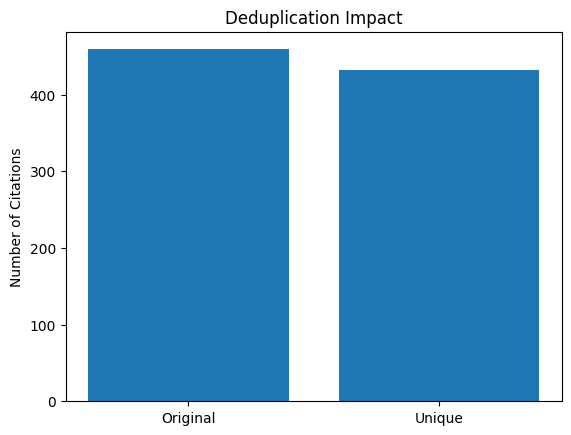

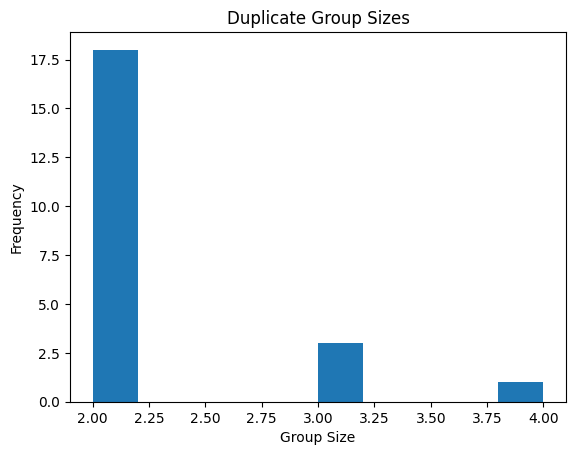

'/content/dedup_exports/plottest.csv'

In [32]:
load_and_clean_citations(
    "/content/biblio_exports/biblio_stabilized_candidate_citations.csv",
    output_path="/content/dedup_exports/plottest.csv",
    show_plots=True
)

In [34]:
df_biblio = pd.read_csv(
    "/content/biblio_exports/biblio_stabilized_candidate_citations.csv",
    low_memory=False
)

len(df_biblio)

549

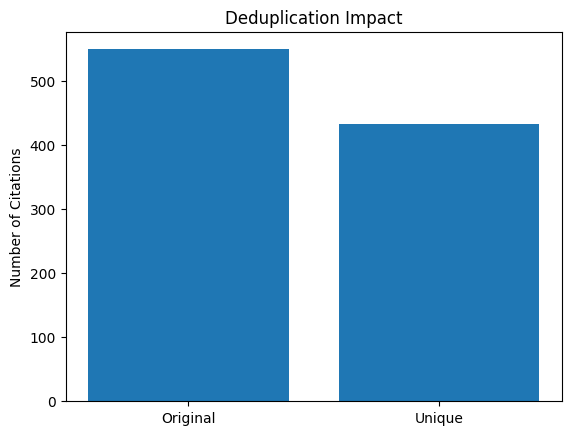

In [36]:
## load deduplicated output
df_unique = pd.read_csv("/content/dedup_exports/plottest.csv")

plt.figure()
plt.bar(["Original", "Unique"], [len(df_biblio), len(df_unique)])
plt.title("Deduplication Impact")
plt.ylabel("Number of Citations")
plt.show()

In [37]:
output_txt = "/content/dedup_exports/bibliography_clean.txt"

with open(output_txt, "w", encoding="utf-8") as f:
    for i, citation in enumerate(df_unique["citation"], start=1):
        f.write(f"{i}. {citation}\n\n")

print("Saved:", output_txt)

Saved: /content/dedup_exports/bibliography_clean.txt


In [45]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

pdf_path = "/content/dedup_exports/bibliography_clean.pdf"

doc = SimpleDocTemplate(pdf_path)
styles = getSampleStyleSheet()

elements = []

## Title
elements.append(Paragraph("Deduplicated Bibliography", styles["Title"]))
elements.append(Spacer(1, 12))

## Add citations
for i, citation in enumerate(df_unique["citation"], start=1):
    text = f"{i}. {citation}"
    elements.append(Paragraph(text, styles["Normal"]))
    elements.append(Spacer(1, 10))

doc.build(elements)

print("Saved PDF:", pdf_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 6.7 MB/s eta 0:00:00
Saved PDF: /content/dedup_exports/bibliography_clean.pdf


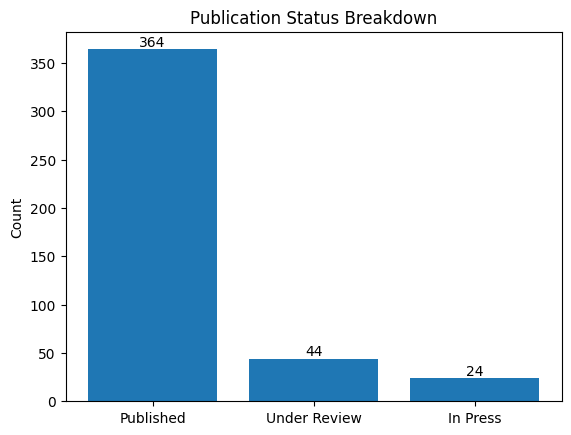

In [40]:
counts = df_unique["status"].value_counts()

plt.figure()
bars = plt.bar(counts.index, counts.values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.title("Publication Status Breakdown")
plt.ylabel("Count")
plt.show()

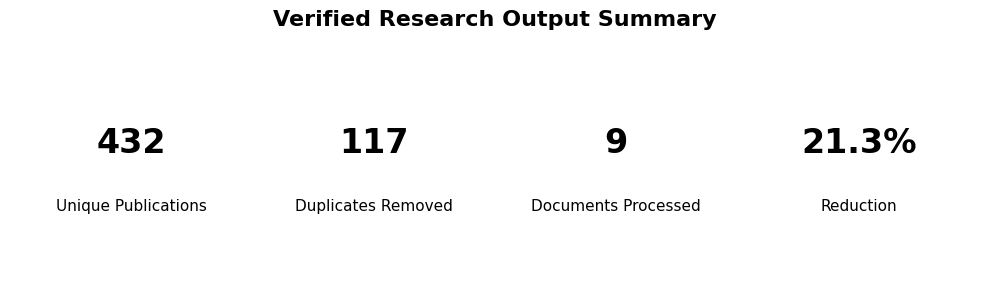

In [44]:
total_raw = len(df_biblio)
total_unique = len(df_unique)
duplicates_removed = total_raw - total_unique
docs_processed = df_corpus["doc_uid"].nunique()
reduction_pct = round(100 * duplicates_removed / total_raw, 1)

metrics = [
    ("Unique Publications", total_unique),
    ("Duplicates Removed", duplicates_removed),
    ("Documents Processed", docs_processed),
    ("Reduction", f"{reduction_pct}%")
]

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

for i, (label, value) in enumerate(metrics):
    x = i / len(metrics) + 0.125

    ax.text(
        x, 0.62, str(value),
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold",
        transform=ax.transAxes
    )

    ax.text(
        x, 0.35, label,
        ha="center",
        va="center",
        fontsize=11,
        transform=ax.transAxes
    )

plt.suptitle("Deduplication Summary", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()